In [1]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import scipy.sparse as sp
import os 
from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots
import pandas as pd

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

from helpers import *

device: cuda


In [2]:
# total time estimation
num_test_samples=1000
num_posterior_samples=100
time_per_sample=10
noise_levels=3
procedures=2
num_diagnostics = 2
total_time = num_diagnostics * num_test_samples*time_per_sample*noise_levels*procedures
print("Total time: ", total_time/(60*60), " hours")

Total time:  33.333333333333336  hours


In [3]:
# check hyperparameter tuning results
#csv_name = f"metrics_diffusion_sxr_{sigma_y_tomo}_zeta{zeta}_lambda{lambda_}.csv"

noise_levels = [0.05, 0.25, 0.5]
lambda_values  = [50, 100, 200, 300, 400, 500]
zeta_values = [0.2, 0.4, 0.6, 0.8, 1.0]

results = []
for noise in noise_levels:
    for zeta in zeta_values:
        for lambda_ in lambda_values:
            csv_name = f"metrics_csv/metrics_diffusion_sxr_{noise}_zeta{zeta}_lambda{lambda_}.csv"
            if os.path.exists(csv_name):
                df = pd.read_csv(csv_name)
                df["noise"] = noise
                df["zeta"] = zeta
                df["lambda"] = lambda_
                results.append(df)
            else:
                print(f"File {csv_name} not found.")

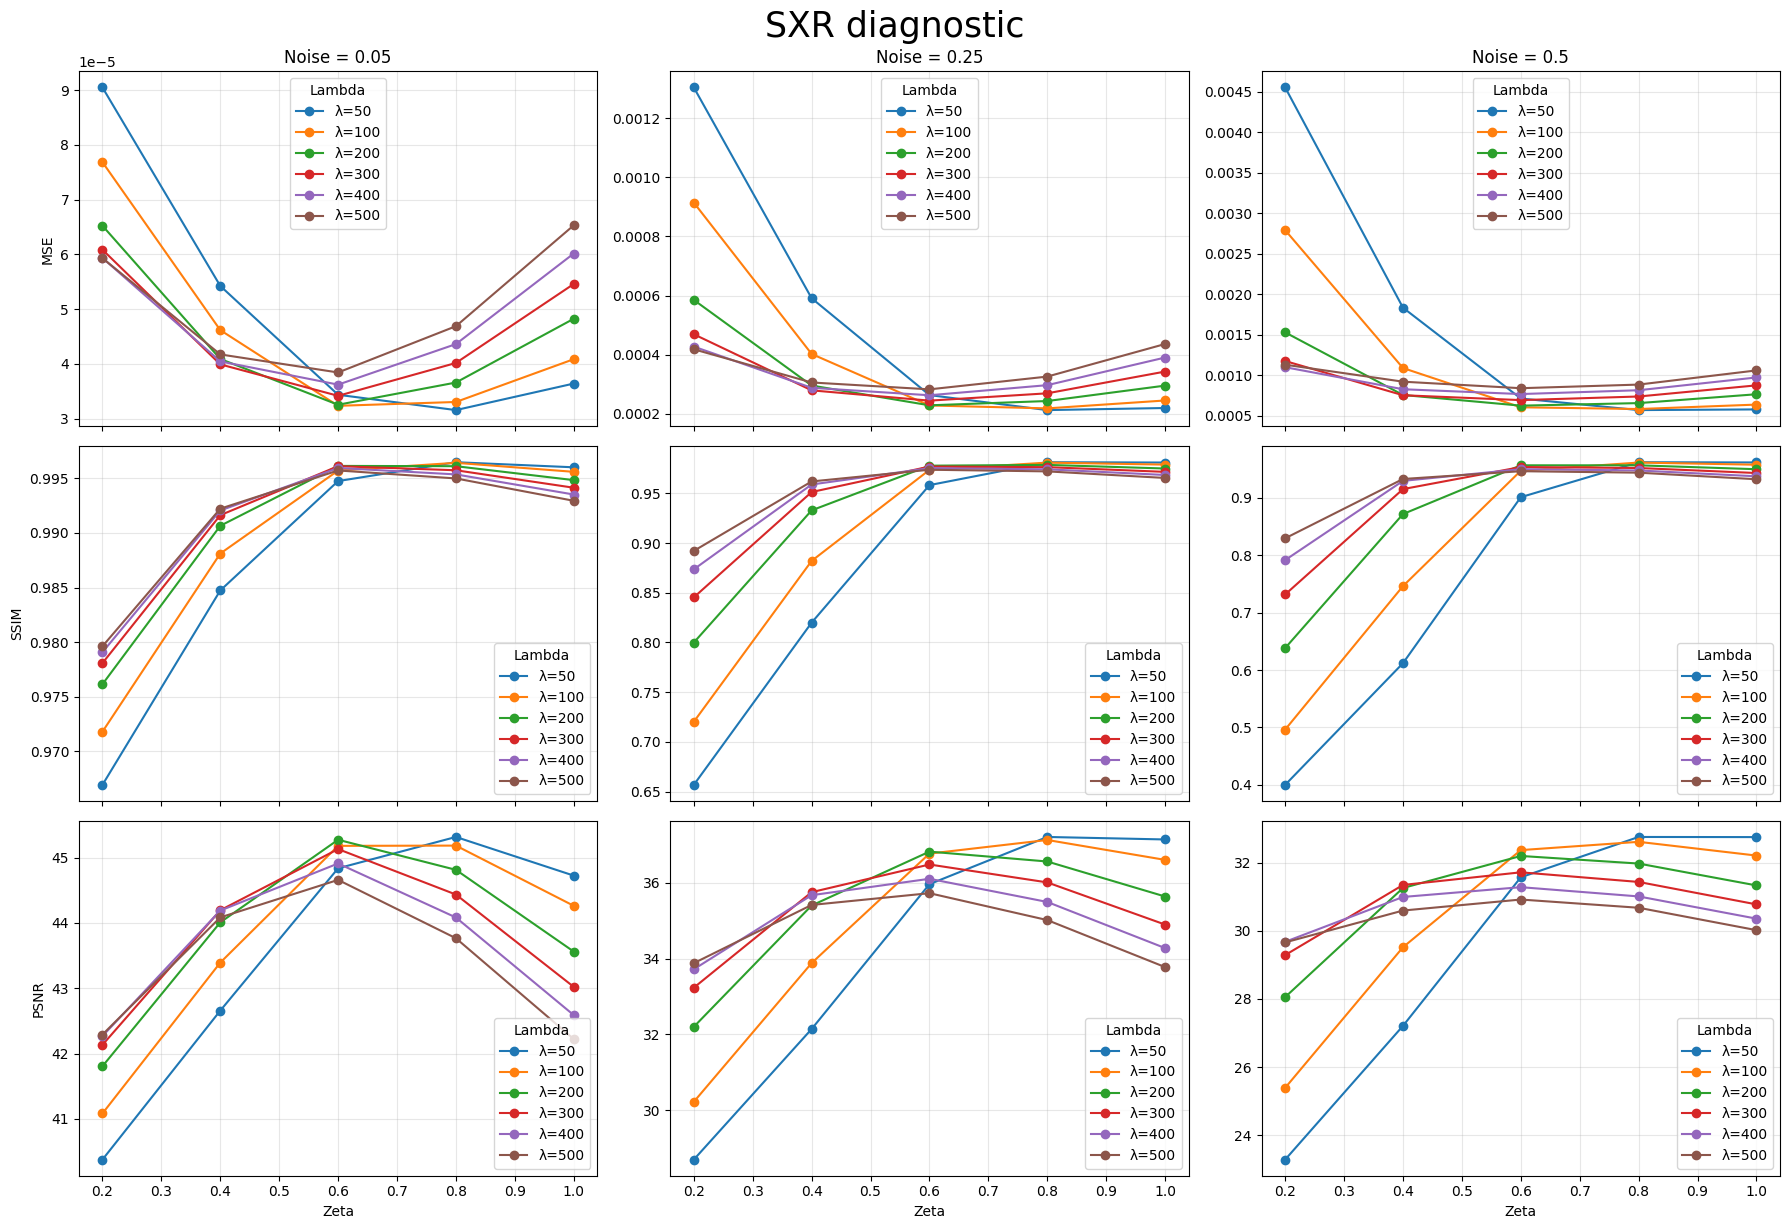

In [19]:
metrics = ["mse", "ssim", "psnr"]
metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}

df_all = pd.concat(results, ignore_index=True)
df_avg = df_all.groupby(["noise", "zeta", "lambda"], as_index=False)[metrics].mean()

fig, ax = plt.subplots(3, 3, figsize=(18, 12), sharex=True)

for r, metric in enumerate(metrics):
    for c, noise in enumerate(noise_levels):
        a = ax[r, c]
        df_noise = df_avg[df_avg["noise"] == noise] 

        for lambda_ in lambda_values:
            df_curve = df_noise[df_noise["lambda"] == lambda_].sort_values("zeta")
            a.plot(df_curve["zeta"], df_curve[metric], marker="o", label=f"λ={lambda_}")

        if r == 0:
            a.set_title(f"Noise = {noise}")
        if c == 0:
            a.set_ylabel(metric_labels[metric])
        if r == 2:
            a.set_xlabel("Zeta")

        a.grid(alpha=0.3)

# keep legends only on the rightmost column to reduce clutter
for r in range(3):
    for i in range(3):
        if r==0:
            ax[r, i].legend(title="Lambda", loc="upper center")
        else:
            ax[r, i].legend(title="Lambda", loc="lower right")

plt.tight_layout()
plt.suptitle("SXR diagnostic", y=1.02, fontsize=25)
plt.savefig("sxr_hyperparameter_tuning_results.png", dpi=300)
plt.show()



In [21]:
# check hyperparameter tuning results
#csv_name = f"metrics_diffusion_sxr_{sigma_y_tomo}_zeta{zeta}_lambda{lambda_}.csv"

noise_levels = [0.05, 0.25, 0.5] #[0.1, 0.5, 1.0]
lambda_values  = [50, 100, 200, 300, 400, 500]
zeta_values = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4]

results = []
for noise in noise_levels:
    for zeta in zeta_values:
        for lambda_ in lambda_values:
            csv_name = f"metrics_csv/metrics_diffusion_dmpx_{noise}_zeta{zeta}_lambda{lambda_}.csv"
            if os.path.exists(csv_name):
                df = pd.read_csv(csv_name)
                df["noise"] = noise
                df["zeta"] = zeta
                df["lambda"] = lambda_
                results.append(df)
            else:
                print(f"File {csv_name} not found.")

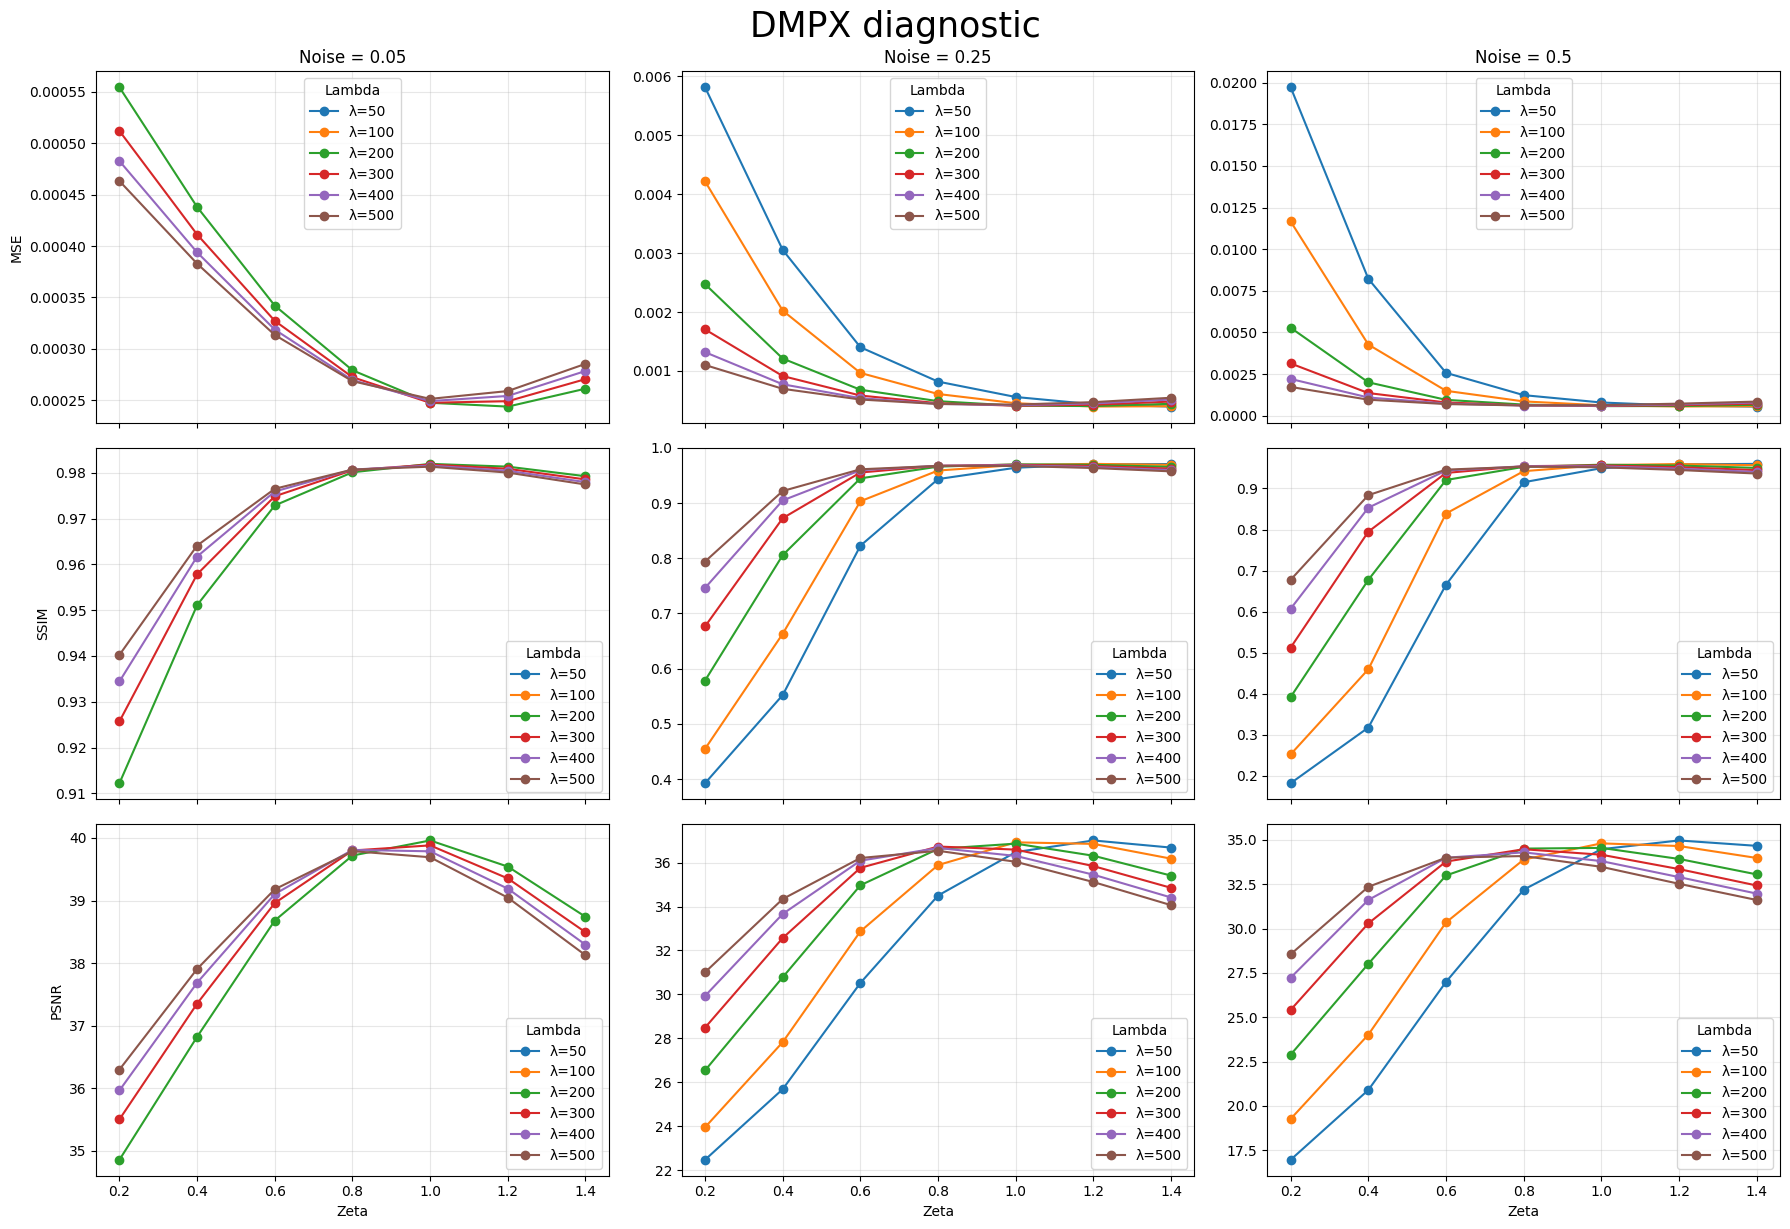

In [31]:
metrics = ["mse", "ssim", "psnr"]
metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}

df_all = pd.concat(results, ignore_index=True)
df_avg = df_all.groupby(["noise", "zeta", "lambda"], as_index=False)[metrics].mean()

fig, ax = plt.subplots(3, 3, figsize=(18, 12), sharex=True)

for r, metric in enumerate(metrics):
    for c, noise in enumerate(noise_levels):
        a = ax[r, c]
        df_noise = df_avg[df_avg["noise"] == noise] 

        for lambda_ in lambda_values:
            if noise>0.05 or lambda_>100:
                df_curve = df_noise[df_noise["lambda"] == lambda_].sort_values("zeta")
                a.plot(df_curve["zeta"], df_curve[metric], marker="o", label=f"λ={lambda_}")
            else:
                a.plot([], [], marker="o", label=f"λ={lambda_}")


        if r == 0:
            a.set_title(f"Noise = {noise}")
        if c == 0:
            a.set_ylabel(metric_labels[metric])
        if r == 2:
            a.set_xlabel("Zeta")

        a.grid(alpha=0.3)

# keep legends only on the rightmost column to reduce clutter
for r in range(3):
    for i in range(3):
        if r==0:
            ax[r, i].legend(title="Lambda", loc="upper center")
        else:
            ax[r, i].legend(title="Lambda", loc="lower right")

plt.tight_layout()
plt.suptitle("DMPX diagnostic", y=1.02, fontsize=25)
plt.savefig("dmpx_hyperparameter_tuning_results.png", dpi=300)
plt.show()



## Pilatus

No clipping

In [8]:
# check hyperparameter tuning results

noise_levels = [0.05, 0.25, 0.5] #[0.1, 0.5, 1.0]
lambda_values  = [25, 50, 100, 200, 300]
zeta_values = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4]

results = []
for noise in noise_levels:
    for zeta in zeta_values:
        for lambda_ in lambda_values:
            csv_name = f"metrics_csv/metrics_diffusion_pilatus_{noise}_zeta{zeta}_lambda{lambda_}_clipFalse.csv"
            if os.path.exists(csv_name):
                df = pd.read_csv(csv_name)
                df["noise"] = noise
                df["zeta"] = zeta
                df["lambda"] = lambda_
                results.append(df)
            else:
                print(f"File {csv_name} not found.")

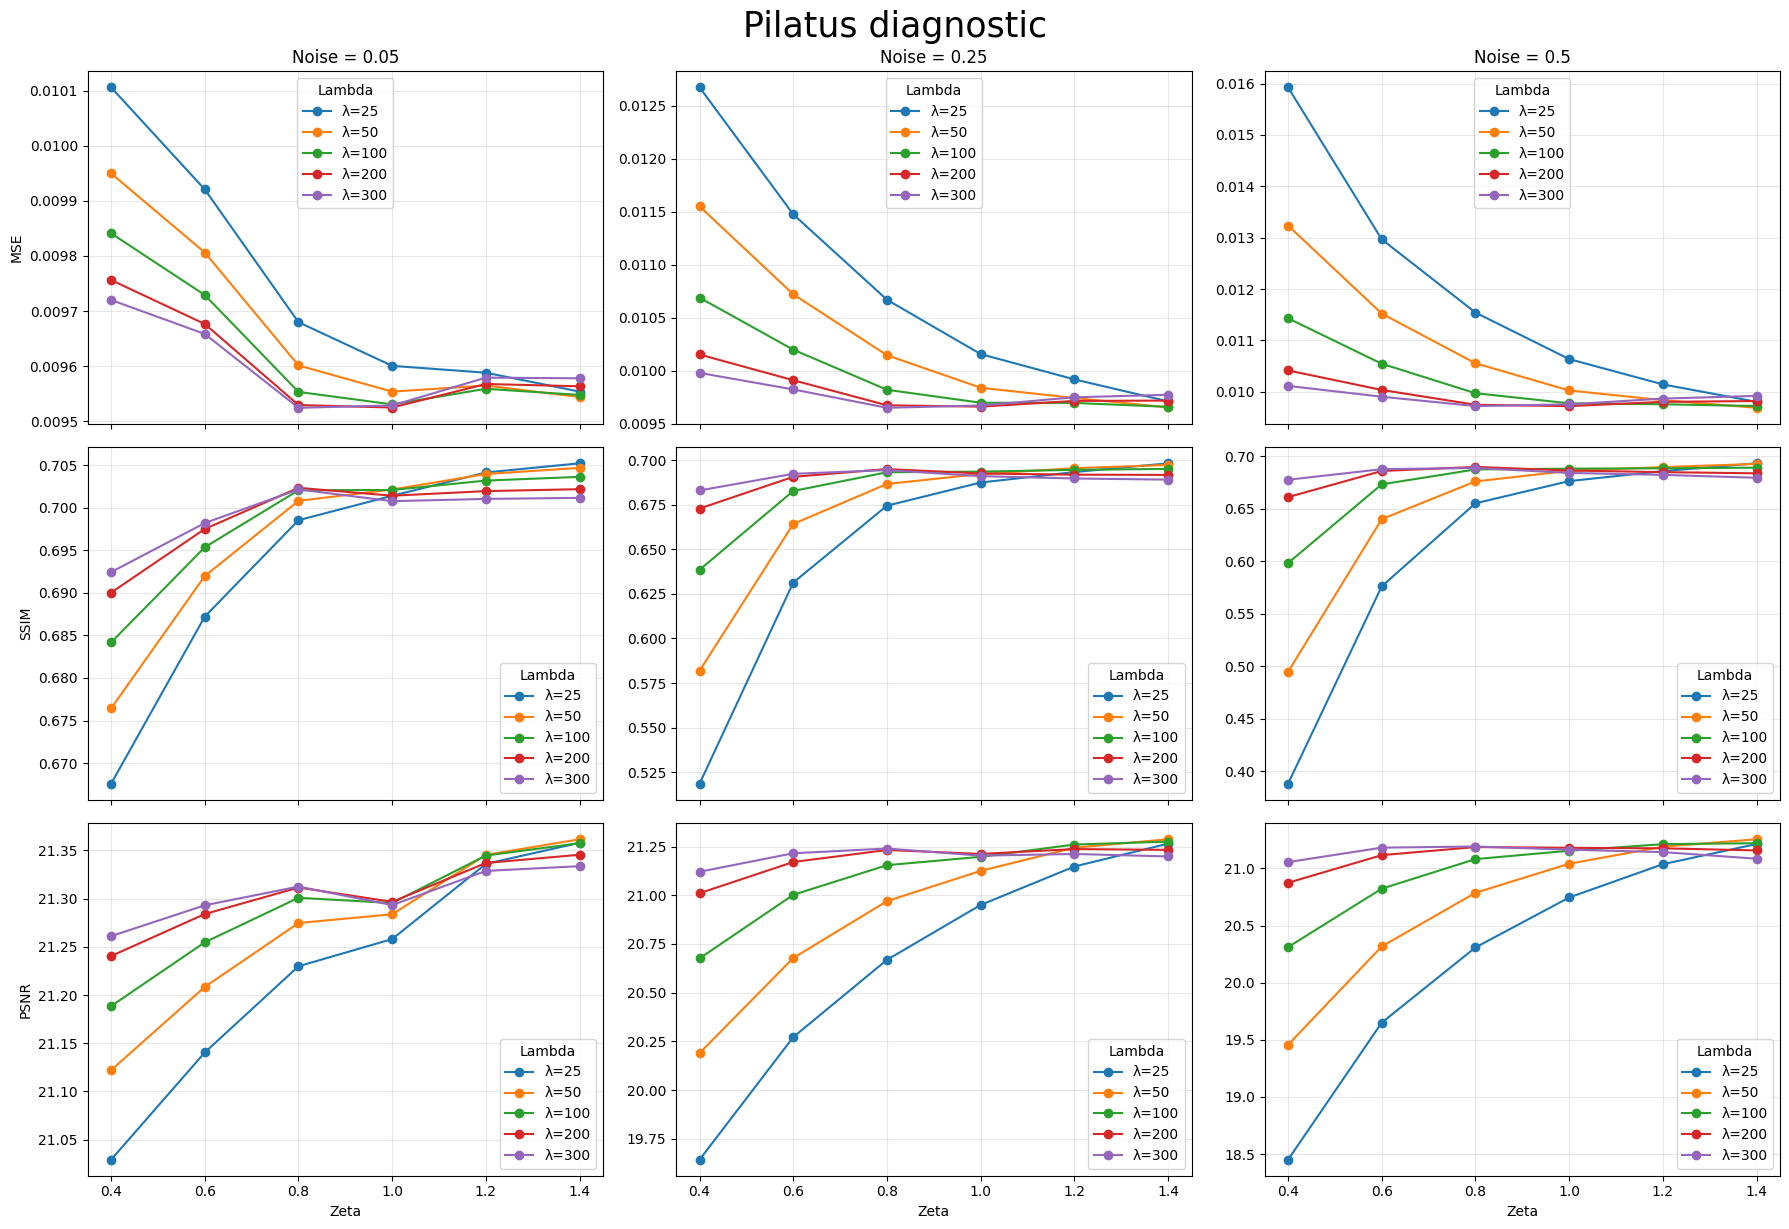

In [9]:
metrics = ["mse", "ssim", "psnr"]
metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}

df_all = pd.concat(results, ignore_index=True)
df_avg = df_all.groupby(["noise", "zeta", "lambda"], as_index=False)[metrics].mean()

fig, ax = plt.subplots(3, 3, figsize=(18, 12), sharex=True)

for r, metric in enumerate(metrics):
    for c, noise in enumerate(noise_levels):
        a = ax[r, c]
        df_noise = df_avg[df_avg["noise"] == noise] 

        for lambda_ in lambda_values:
            #if noise>0.05 or lambda_>100:
            df_curve = df_noise[df_noise["lambda"] == lambda_].sort_values("zeta")
            a.plot(df_curve["zeta"], df_curve[metric], marker="o", label=f"λ={lambda_}")
            # else:
            #     a.plot([], [], marker="o", label=f"λ={lambda_}")


        if r == 0:
            a.set_title(f"Noise = {noise}")
        if c == 0:
            a.set_ylabel(metric_labels[metric])
        if r == 2:
            a.set_xlabel("Zeta")

        a.grid(alpha=0.3)

# keep legends only on the rightmost column to reduce clutter
for r in range(3):
    for i in range(3):
        if r==0:
            ax[r, i].legend(title="Lambda", loc="upper center")
        else:
            ax[r, i].legend(title="Lambda", loc="lower right")

plt.tight_layout()
plt.suptitle("Pilatus diagnostic", y=1.02, fontsize=25)
plt.savefig("pilatus_noclip_hyperparameter_tuning_results.png", dpi=300)
plt.show()



With clipping

In [10]:
# check hyperparameter tuning results

noise_levels = [0.05, 0.25, 0.5] #[0.1, 0.5, 1.0]
lambda_values  = [25, 50, 100, 200, 300]
zeta_values = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4]

results = []
for noise in noise_levels:
    for zeta in zeta_values:
        for lambda_ in lambda_values:
            csv_name = f"metrics_csv/metrics_diffusion_pilatus_{noise}_zeta{zeta}_lambda{lambda_}_clipTrue.csv"
            if os.path.exists(csv_name):
                df = pd.read_csv(csv_name)
                df["noise"] = noise
                df["zeta"] = zeta
                df["lambda"] = lambda_
                results.append(df)
            else:
                print(f"File {csv_name} not found.")

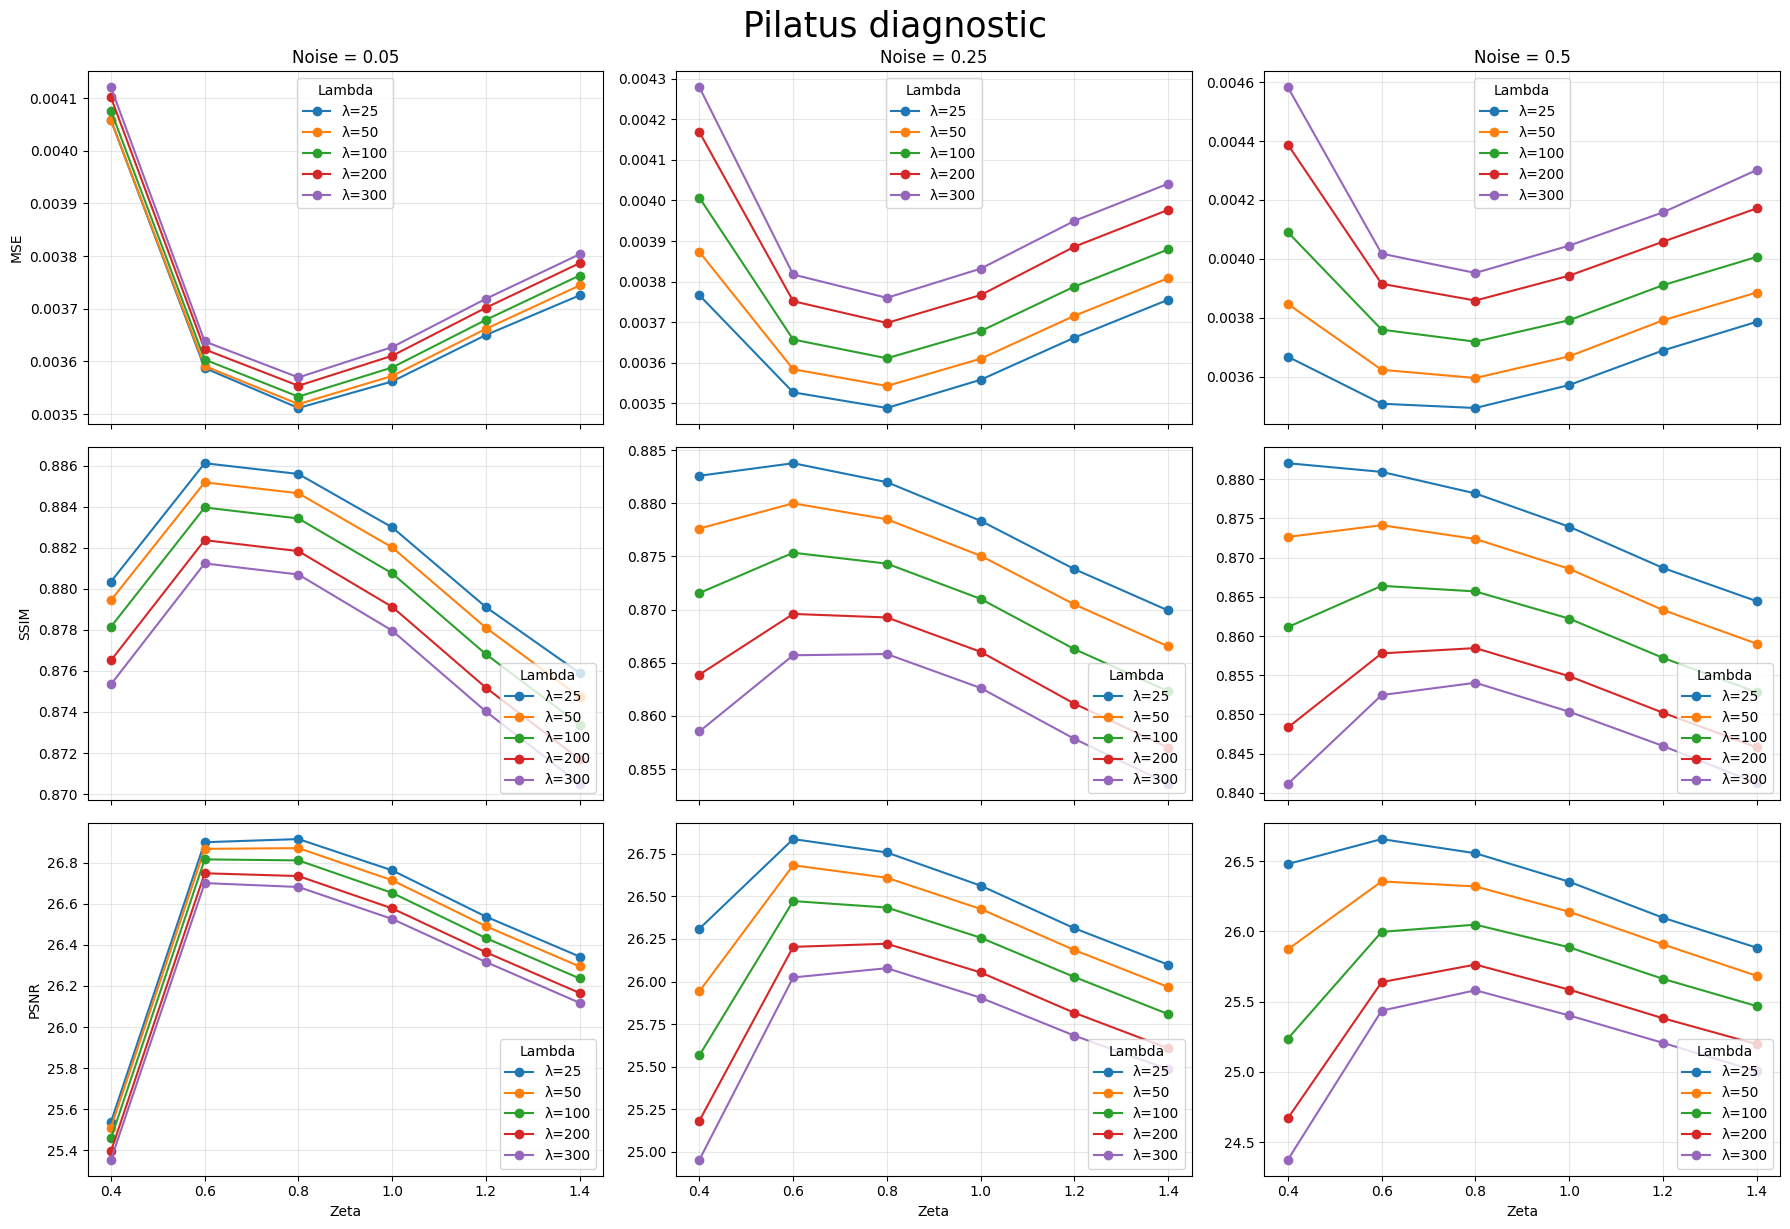

In [11]:
metrics = ["mse", "ssim", "psnr"]
metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}

df_all = pd.concat(results, ignore_index=True)
df_avg = df_all.groupby(["noise", "zeta", "lambda"], as_index=False)[metrics].mean()

fig, ax = plt.subplots(3, 3, figsize=(18, 12), sharex=True)

for r, metric in enumerate(metrics):
    for c, noise in enumerate(noise_levels):
        a = ax[r, c]
        df_noise = df_avg[df_avg["noise"] == noise] 

        for lambda_ in lambda_values:
            #if noise>0.05 or lambda_>100:
            df_curve = df_noise[df_noise["lambda"] == lambda_].sort_values("zeta")
            a.plot(df_curve["zeta"], df_curve[metric], marker="o", label=f"λ={lambda_}")
            # else:
            #     a.plot([], [], marker="o", label=f"λ={lambda_}")


        if r == 0:
            a.set_title(f"Noise = {noise}")
        if c == 0:
            a.set_ylabel(metric_labels[metric])
        if r == 2:
            a.set_xlabel("Zeta")

        a.grid(alpha=0.3)

# keep legends only on the rightmost column to reduce clutter
for r in range(3):
    for i in range(3):
        if r==0:
            ax[r, i].legend(title="Lambda", loc="upper center")
        else:
            ax[r, i].legend(title="Lambda", loc="lower right")

plt.tight_layout()
plt.suptitle("Pilatus diagnostic", y=1.02, fontsize=25)
plt.savefig("pilatus_withclip_hyperparameter_tuning_results.png", dpi=300)
plt.show()



# Check phantom analysis results

## SXR

Noise level: 0.05
MSE: 0.000026 +- 0.0001
SSIM: 0.996104 +- 0.0074
PSNR: 47.074031 +- 3.1666
Noise level: 0.25
MSE: 0.000124 +- 0.0001
SSIM: 0.985892 +- 0.0110
PSNR: 40.046038 +- 3.1298
Noise level: 0.5
MSE: 0.000312 +- 0.0002
SSIM: 0.971575 +- 0.0176
PSNR: 35.997982 +- 3.1973


Noise level: 0.05, procedure=True
MSE: 95.763879 +- 247.5900
SSIM: 0.981761 +- 0.0281
PSNR: 40.836958 +- 7.1251
Noise level: 0.25, procedure=True
MSE: 149.169221 +- 304.4846
SSIM: 0.970827 +- 0.0303
PSNR: 36.418206 +- 5.0711
Noise level: 0.5, procedure=True
MSE: 218.593167 +- 367.4471
SSIM: 0.956487 +- 0.0341
PSNR: 33.644113 +- 4.0949


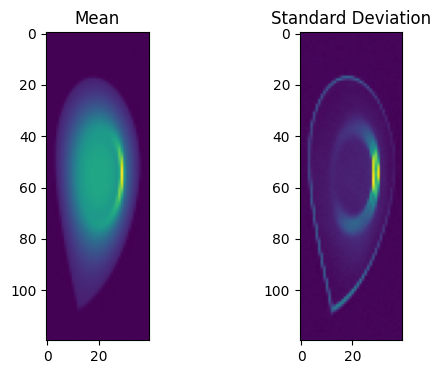

In [5]:
# check sxr phantom analysis results
#csv_name = f"metrics_diffusion_sxr_{sigma_y_tomo}_zeta{zeta}_lambda{lambda_}.csv"

noise_levels = [0.05, 0.25, 0.5]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis/metrics_diffusion_sxr_{noise}_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis/metrics_diffusion_sxr_{noise}_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics for the first noise-level entry (0.05)

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")


means,stds = np.load("metrics_csv_phantom_analysis/post_means_sxr_0.05_false.npy")[20,:], np.load("metrics_csv_phantom_analysis/post_stds_sxr_0.05_false.npy")[20,:]
fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax[0].imshow(means.reshape(120,40))
ax[0].set_title("Mean")
ax[1].imshow(stds.reshape(120,40))
ax[1].set_title("Standard Deviation")
plt.show()

# DMPX

Noise level: 0.05
MSE: 0.000111 +- 0.0002
SSIM: 0.988979 +- 0.0110
PSNR: 42.727900 +- 5.3022
Noise level: 0.25
MSE: 0.000208 +- 0.0003
SSIM: 0.978910 +- 0.0175
PSNR: 39.475048 +- 4.9365
Noise level: 0.5
MSE: 0.000313 +- 0.0004
SSIM: 0.968405 +- 0.0228
PSNR: 37.330657 +- 4.6776


Noise level: 0.05, procedure=True
MSE: inf +- nan
SSIM: 0.911388 +- 0.2228
PSNR: -inf +- nan
Noise level: 0.25, procedure=True
MSE: 223.146534 +- 477.7519
SSIM: 0.953737 +- 0.0435
PSNR: 34.724529 +- 5.7871
Noise level: 0.5, procedure=True
MSE: 266.889396 +- 537.4116
SSIM: 0.943303 +- 0.0470
PSNR: 33.493747 +- 5.3089


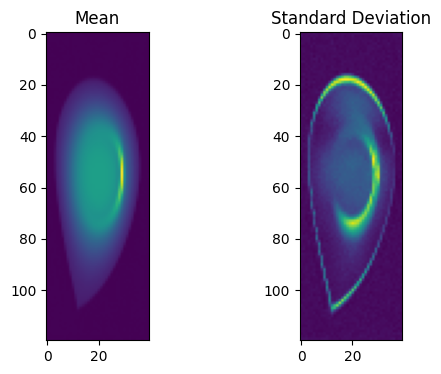

In [8]:
noise_levels = [0.05, 0.25, 0.5]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis/metrics_diffusion_dmpx_{noise}_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis/metrics_diffusion_dmpx_{noise}_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics for the first noise-level entry (0.05)

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

means,stds = np.load("metrics_csv_phantom_analysis/post_means_dmpx_0.05_false.npy")[20,:], np.load("metrics_csv_phantom_analysis/post_stds_dmpx_0.05_false.npy")[20,:]
fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax[0].imshow(means.reshape(120,40))
ax[0].set_title("Mean")
ax[1].imshow(stds.reshape(120,40))
ax[1].set_title("Standard Deviation")
plt.show()

In [7]:
# check how many nan/inf values in the psnr of the dmpx phantom analysis results, for procedure=True and noise level 0.05
# check also for which indices they occur, plot the corresponding test samples and reconstructions to understand why they occur, and print also the estimated alpha vs scaling applied for those samples
csv_name = f"metrics_csv_phantom_analysis/metrics_diffusion_dmpx_0.05_true.csv"
bad_indices = []
if os.path.exists(csv_name):
    df = pd.read_csv(csv_name)
    num_nan = df["psnr"].isna().sum()
    num_inf = np.isinf(df["psnr"]).sum()
    print(f"Number of NaN values in PSNR: {num_nan}")
    print(f"Number of Inf values in PSNR: {num_inf}")
    bad_indices = df[df["psnr"].isna() | np.isinf(df["psnr"])].index.tolist()
else:
    print(f"File {csv_name} not found.")   

# Load test samples
samples_idxs = np.arange(0, 1000)
test_samples_path = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy")
test_samples = np.load(test_samples_path)[samples_idxs]

# print applied scaling and estimated alpha, corresponding to fields "scaling" and "alpha" in the csv file, for the bad indices
bad_idx_scaling_alpha = df.loc[bad_indices, ["scaling", "alpha"]]
bad_idx_noise = df.loc[bad_indices, "sigma_used"]

Number of NaN values in PSNR: 0
Number of Inf values in PSNR: 10


In [9]:
print(bad_idx_scaling_alpha)

        scaling        alpha
172  512.580994   824.145264
221  568.740295   721.596313
238  645.826843  1601.982056
271  810.303284  1985.905884
368  196.595337   398.827454
594  896.891602  1405.882446
718  125.172928   272.208984
758  893.998718  1985.162476
937  914.384521  1311.057739
961  603.548950   802.284058


In [10]:
print(bad_idx_noise)

172    0.024450
221    0.025929
238    0.023129
271    0.020589
368    0.022439
594    0.021482
718    0.019966
758    0.020316
937    0.024300
961    0.024281
Name: sigma_used, dtype: float64


## Pilatus, clip=False

Noise level: 0.05
MSE: 0.007707 +- 0.0069
SSIM: 0.748029 +- 0.1002
PSNR: 22.463075 +- 3.6851
Noise level: 0.25
MSE: 0.007969 +- 0.0070
SSIM: 0.737318 +- 0.0992
PSNR: 22.242948 +- 3.5639
Noise level: 0.5
MSE: 0.008192 +- 0.0071
SSIM: 0.728675 +- 0.0988
PSNR: 22.078659 +- 3.4900


Noise level: 0.05, procedure=True
MSE: 2544.468926 +- 3728.1732
SSIM: 0.739125 +- 0.0979
PSNR: 22.152248 +- 3.5980
Noise level: 0.25, procedure=True
MSE: 2618.807413 +- 3756.2762
SSIM: 0.727448 +- 0.0975
PSNR: 21.925866 +- 3.5255
Noise level: 0.5, procedure=True
MSE: 2704.678551 +- 3833.4920
SSIM: 0.719203 +- 0.0980
PSNR: 21.784524 +- 3.4878


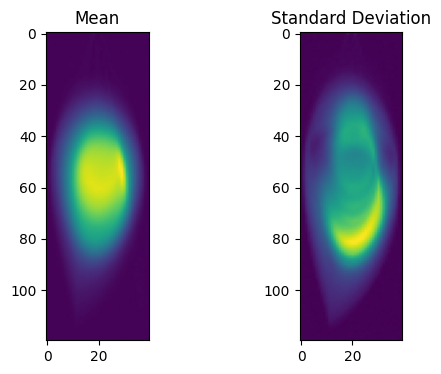

In [11]:
noise_levels = [0.05, 0.25, 0.5]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis/metrics_diffusion_pilatus_{noise}_clipFalse_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis/metrics_diffusion_pilatus_{noise}_clipFalse_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics for the first noise-level entry (0.05)

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

means,stds = np.load("metrics_csv_phantom_analysis/post_means_pilatus_0.05_clipFalse_false.npy")[20,:], np.load("metrics_csv_phantom_analysis/post_stds_pilatus_0.05_clipFalse_false.npy")[20,:]
fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax[0].imshow(means.reshape(120,40))
ax[0].set_title("Mean")
ax[1].imshow(stds.reshape(120,40))
ax[1].set_title("Standard Deviation")
plt.show()

## Pilatus, clip=True

Noise level: 0.05
MSE: 0.002395 +- 0.0034
SSIM: 0.914484 +- 0.0619
PSNR: 29.002218 +- 5.0992
Noise level: 0.25
MSE: 0.002508 +- 0.0033
SSIM: 0.906884 +- 0.0625
PSNR: 28.569908 +- 4.8916
Noise level: 0.5
MSE: 0.002676 +- 0.0034
SSIM: 0.898714 +- 0.0645
PSNR: 28.063343 +- 4.6788


Noise level: 0.05, procedure=True
MSE: inf +- nan
SSIM: 0.878542 +- 0.1382
PSNR: -inf +- nan
Noise level: 0.25, procedure=True
MSE: 992.748775 +- 1747.3379
SSIM: 0.896942 +- 0.0640
PSNR: 27.198190 +- 4.3873
Noise level: 0.5, procedure=True
MSE: 1068.766107 +- 1851.3834
SSIM: 0.889604 +- 0.0645
PSNR: 26.808877 +- 4.2097


/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


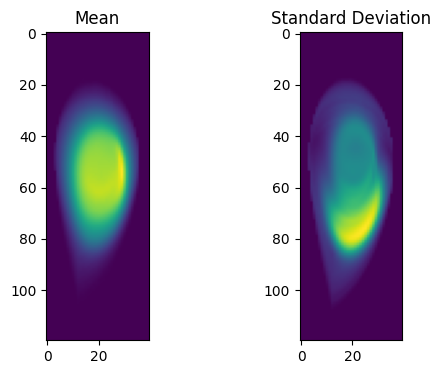

In [12]:
noise_levels = [0.05, 0.25, 0.5]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis/metrics_diffusion_pilatus_{noise}_clipTrue_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis/metrics_diffusion_pilatus_{noise}_clipTrue_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics for the first noise-level entry (0.05)

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse", "ssim", "psnr"]
    metric_labels = {"mse": "MSE", "ssim": "SSIM", "psnr": "PSNR"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

means,stds = np.load("metrics_csv_phantom_analysis/post_means_pilatus_0.05_clipTrue_false.npy")[20,:], np.load("metrics_csv_phantom_analysis/post_stds_pilatus_0.05_clipTrue_false.npy")[20,:]
fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax[0].imshow(means.reshape(120,40))
ax[0].set_title("Mean")
ax[1].imshow(stds.reshape(120,40))
ax[1].set_title("Standard Deviation")
plt.show()

In [14]:
# check how many nan/inf values in the psnr of the pilatus phantom analysis results, for procedure=True and noise level 0.05
# check also for which indices they occur, plot the corresponding test samples and reconstructions to understand why they occur, and print also the estimated alpha vs scaling applied for those samples
csv_name = f"metrics_csv_phantom_analysis/metrics_diffusion_pilatus_0.05_clipTrue_true.csv"
bad_indices = []
if os.path.exists(csv_name):
    df = pd.read_csv(csv_name)
    num_nan = df["psnr"].isna().sum()
    num_inf = np.isinf(df["psnr"]).sum()
    print(f"Number of NaN values in PSNR: {num_nan}")
    print(f"Number of Inf values in PSNR: {num_inf}")
    bad_indices = df[df["psnr"].isna() | np.isinf(df["psnr"])].index.tolist()
else:
    print(f"File {csv_name} not found.")   

# Load test samples
samples_idxs = np.arange(0, 1000)
test_samples_path = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy")
test_samples = np.load(test_samples_path)[samples_idxs]

# print applied scaling and estimated alpha, corresponding to fields "scaling" and "alpha" in the csv file, for the bad indices
bad_idx_scaling_alpha = df.loc[bad_indices, ["scaling", "alpha"]]
bad_idx_noise = df.loc[bad_indices, "sigma_used"]

Number of NaN values in PSNR: 1
Number of Inf values in PSNR: 6


In [15]:
print(bad_idx_noise)

75     0.022148
185    0.015272
187    0.020191
219    0.020764
238    0.019377
827    0.017242
852    0.018637
Name: sigma_used, dtype: float64


In [16]:
print("Running pipeline on diagnostic {} ".format(str("diag")))

Running pipeline on diagnostic diag 


In [13]:
df_noise[metrics].median()

mse      0.000096
ssim     0.988199
psnr    40.101801
dtype: float64

In [11]:
df_noise[metrics].quantile([0.99])

,mse,ssim,psnr
0.99,0.000145,0.999132,53.418525


In [22]:
results[0].keys()

Index(['sample_idx', 'psnr', 'ssim', 'mse', 'post_std_mean', 'sigma_used',
       'alpha', 'scaling', 'noise'],
      dtype='str')

In [24]:
results[0]["post_std_mean"][0]

np.float64(0.0068165860138833)